In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# --- STAGE 1: LOAD ---
# Creating the recommended dataset: Predict Score based on Hours studied
data = {
    "Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Score": [35, 40, 50, 55, 60, 66, 70, 78, 85, 90]
}
df = pd.DataFrame(data)
print("--- Stage 1: Data Loaded ---")
print(df.head())

--- Stage 1: Data Loaded ---
   Hours  Score
0      1     35
1      2     40
2      3     50
3      4     55
4      5     60


In [ ]:
# --- STAGE 2: INSPECT ---
print("\n--- Stage 2: Inspecting Data ---")
print(df.info())
print(df.describe())
print("Missing values:\n", df.isna().sum())


--- Stage 2: Inspecting Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Hours   10 non-null     int64
 1   Score   10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes
None
          Hours      Score
count  10.00000  10.000000
mean    5.50000  62.900000
std     3.02765  18.411651
min     1.00000  35.000000
25%     3.25000  51.250000
50%     5.50000  63.000000
75%     7.75000  76.000000
max    10.00000  90.000000
Missing values:
 Hours    0
Score    0
dtype: int64


In [ ]:
# --- STAGE 3: PREPROCESS ---
# Filling missing values with the median (standard cleaning step)
df["Hours"] = df["Hours"].fillna(df["Hours"].median())
df["Score"] = df["Score"].fillna(df["Score"].median())
print("\n--- Stage 3: Preprocessing Complete ---")
print("Missing after preprocessing:\n", df.isna().sum())


--- Stage 3: Preprocessing Complete ---
Missing after preprocessing:
 Hours    0
Score    0
dtype: int64


In [ ]:
# --- STAGE 4: SPLIT ---
# Defining features (X) and target (y)
X = df[["Hours"]]
y = df["Score"]

# Splitting into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\n--- Stage 4: Data Split (Train: {X_train.shape[0]}, Test: {X_test.shape[0]}) ---")


--- Stage 4: Data Split (Train: 8, Test: 2) ---


In [ ]:
# --- STAGE 5: TRAIN ---
model = LinearRegression()
model.fit(X_train, y_train)
print("\n--- Stage 5: Model Trained ---")


--- Stage 5: Model Trained ---


In [ ]:
# --- STAGE 6: PREDICT ---
y_pred = model.predict(X_test)
print("\n--- Stage 6: Predictions Generated ---")
print("First few predictions:", y_pred.round(2))


--- Stage 6: Predictions Generated ---
First few predictions: [83.7 42.3]


In [ ]:
# --- STAGE 7: EVALUATE ---
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\n--- Stage 7: Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


--- Stage 7: Evaluation Metrics ---
Mean Squared Error (MSE): 3.50
R-squared (R2): 0.99



--- Stage 8: User Output ---
   Hours  Actual  Predicted
1      2      40       42.3
8      9      85       83.7

Summary Report:
Model: Linear Regression
The model predicts scores with an R2 of 0.99, indicating a strong fit.


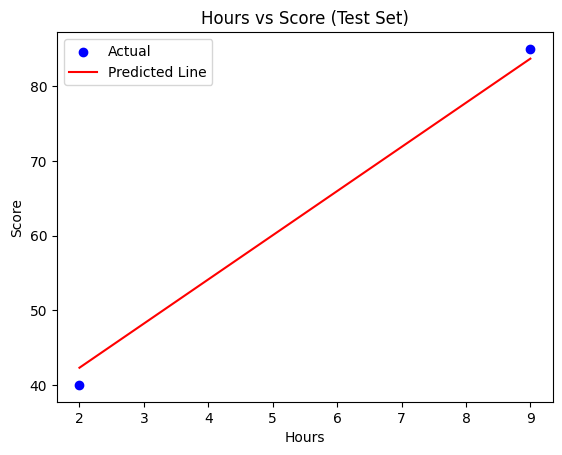

In [ ]:
# --- STAGE 8: USER OUTPUT ---
print("\n--- Stage 8: User Output ---")

# (A) Actual vs Predicted Table
result = X_test.copy()
result["Actual"] = y_test.values
result["Predicted"] = y_pred.round(2)
print(result.sort_values("Hours"))

# (B) Summary Report
print("\nSummary Report:")
print(f"Model: Linear Regression")
print(f"The model predicts scores with an R2 of {r2:.2f}, indicating a strong fit.")

# (C) Simple Plot
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted Line')
plt.title("Hours vs Score (Test Set)")
plt.xlabel("Hours")
plt.ylabel("Score")
plt.legend()
plt.show()